# Gene level evaluation

In this notebook we focus on how to train InterScale using the molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w) which we preprocessed in the [previous tutorial](./1_model_training.ipynb). 

**Requirements**:

- inference results in the anndata object 
- trained model to load inference results

## Import packages

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

import warnings

# gene program import
import gseapy as gp
import matplotlib as mpl
import pandas as pd

warnings.filterwarnings("ignore")

In [2]:
import interscale
from interscale.config import load_config
from interscale.evaluation import (
    gene_loadings,
    calculate_gene_ranks,
    latent_rank_report,
    get_genes_dim,
    calculate_dim_importance,
)

interscale.tl.set_full_reproducibility()

In [4]:
import sys

# Find repo root by locating paths.py
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "legnini"
RESULTS_DIR = Path(f"{BASE_DIR_PROJECT}/results/{DATA}")

## Load data and model

To load the model, check in the previous tutorial [1_model_training.ipynb](1_model_training.ipynb) in the model training for the path where the model was saved to. 

In [5]:
adata = sc.read_h5ad(f"{BASE_DIR_PROJECT}/data/{DATA}_trained.h5ad")
cfg = load_config(Path(f"{BASE_DIR_PROJECT}/config_files/{DATA}_example.yaml"))

In [5]:
adata = sc.read_h5ad("/home/lehnerl/Arbeit/data/legnini_trained.h5ad")
cfg = load_config(Path("/home/lehnerl/Arbeit/github/interscale/config_files/test.yaml"))

In [9]:
interscale.model.CombinedModel._setup_anndata(
    adata=adata,
    prediction_task=cfg.dataset.prediction_task,
    layer_key=cfg.dataset.layer_key,
    sample_key_list=cfg.dataset.sample_key,
    prediction_obs=cfg.dataset.prediction_obs,
    view_registry=False,
)

dual_combined_model = interscale.model.CombinedModel.load(
    "/home/lehnerl/Arbeit/models/",
    adata,
    cfg,
    local_component=True,
    global_component=True,
)

Loading model from /home/lehnerl/Arbeit/models/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


## Gene rank analysis 

First we check whether the local and global embeddings capture different genes and which genes are better learned by the local vs global component. 

 For each gene, we computed:
Local Rank: Ranking based on local model reconstruction performance XL 
Global Rank: Ranking based on global model reconstruction performance XG 
Rank Difference: Local Rank - Global Rank, indicating model preference
Average Rank: (Local Rank + Global Rank) / 2, representing overall predictive quality

In [10]:
df = calculate_gene_ranks(adata, layers_local_pred="_y_pred_local", layers_global_pred="_y_pred_global")

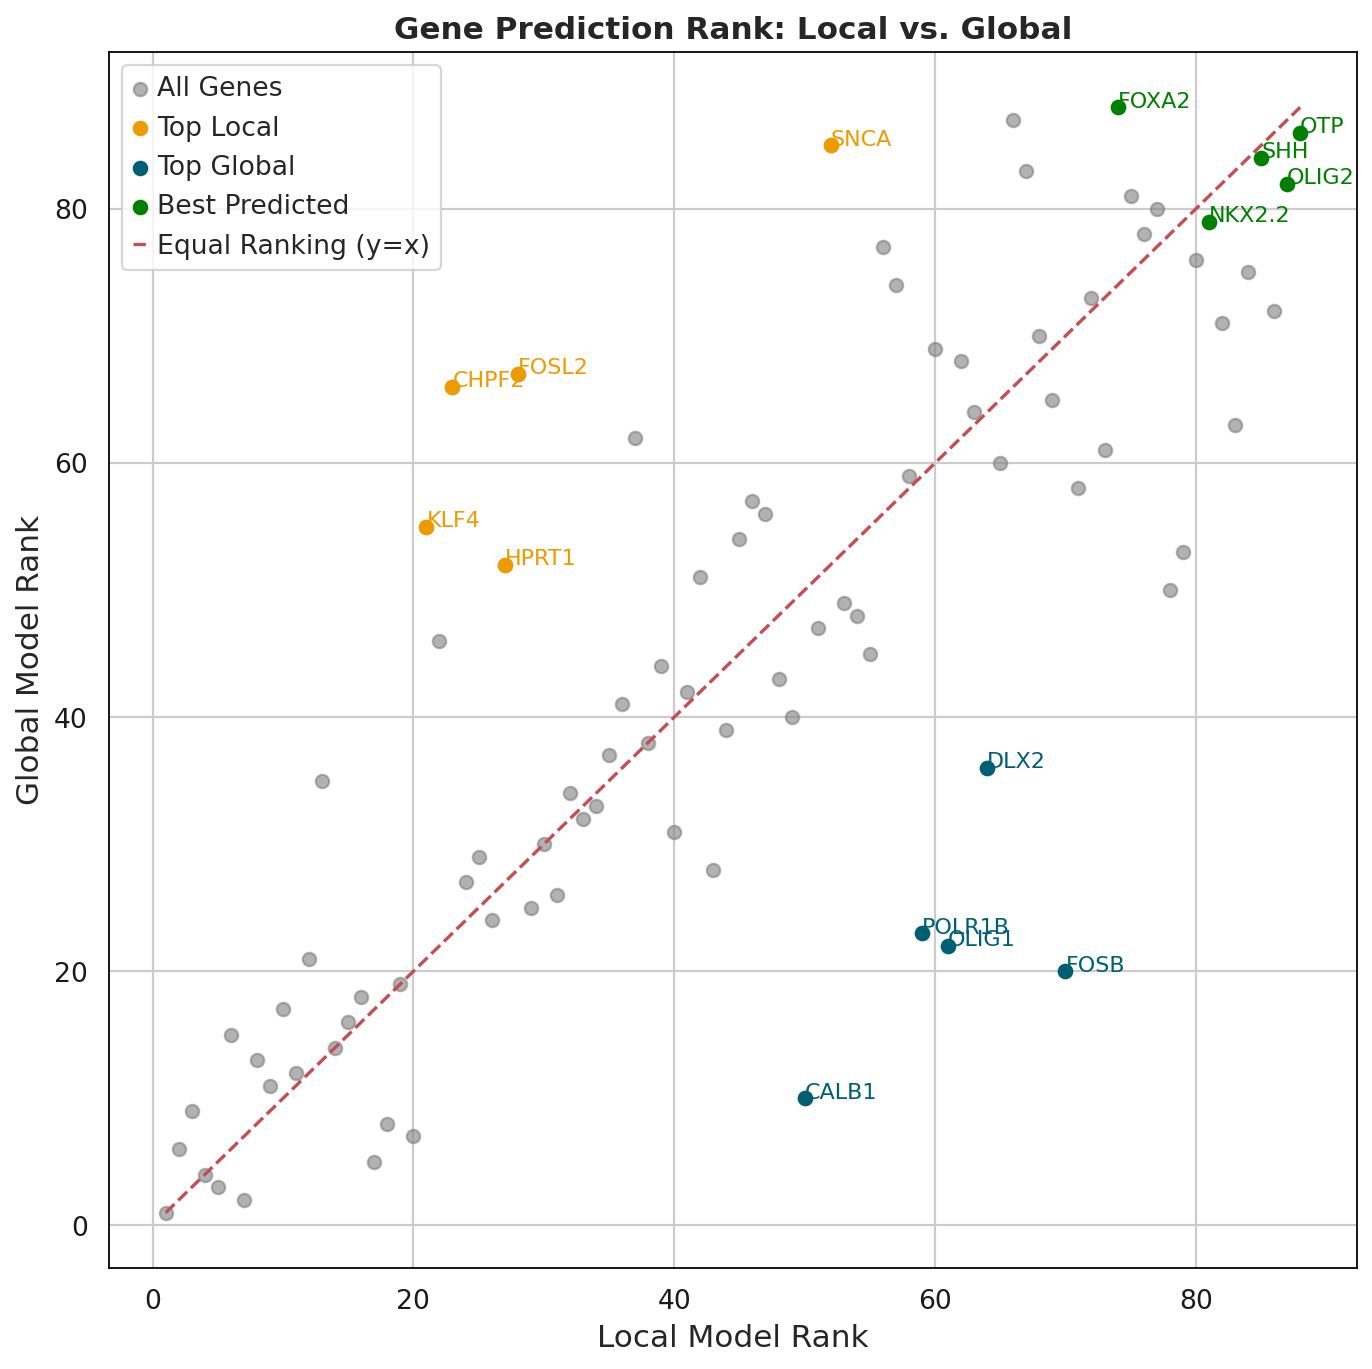

In [12]:
interscale.pl.gene_ranks(df, top_n=5)

In [15]:
from interscale.pl import gene_ranks

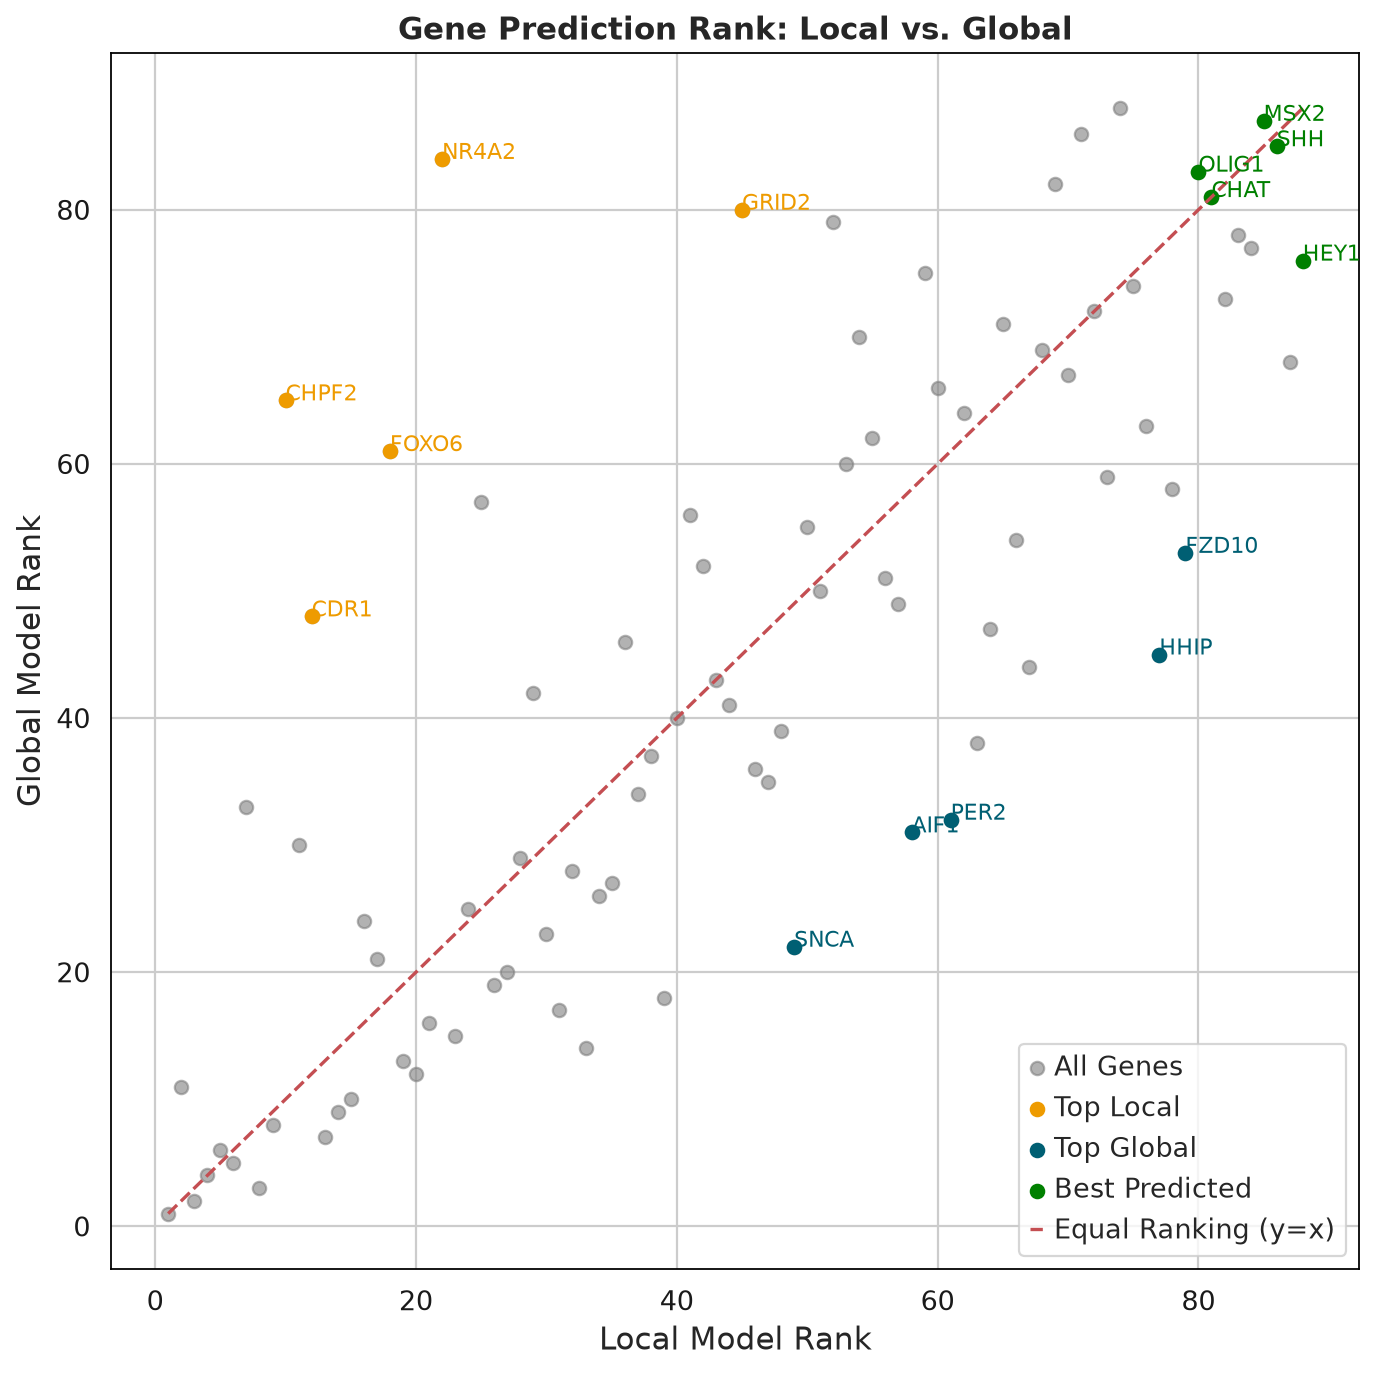

In [16]:
gene_ranks(df, top_n=5)

## Gene loadings

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

In [17]:
gene_loadings(
    adata,
    dual_combined_model,
    local_latent_key="_global_emb",
    global_latent_key="_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_split_key', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'spatial_neighbors'
    obsm: '_attn_matrix', '_global_emb', '_local_emb', 'spatial'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: '_y_pred_global', '_y_pred_local', 'log1p_norm', 'norm_ftsqrt', 'raw'
    obsp: 'spatial_connectivities', 'spatial_distances'

First we check the correlation between each embedding dimension. If the matrix is almost diagonal, we can assume linea independence.

In [18]:
# Check rank:
rep_global = latent_rank_report(adata, z_key="_global_emb")
rep_local = latent_rank_report(adata, z_key="_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 43743, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 43762, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}


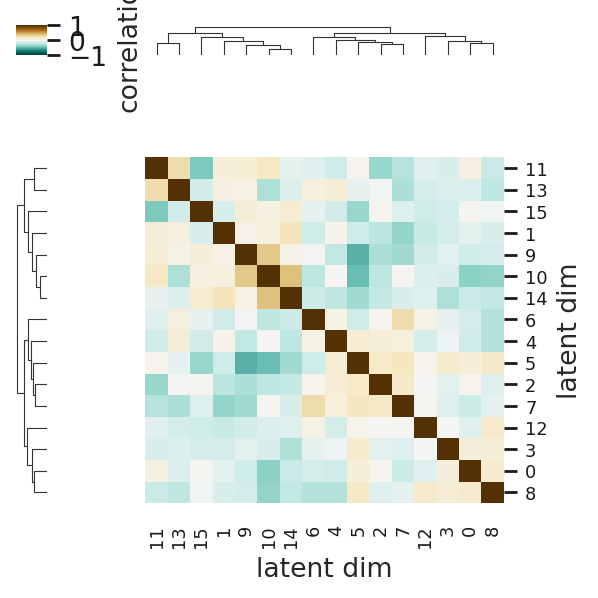

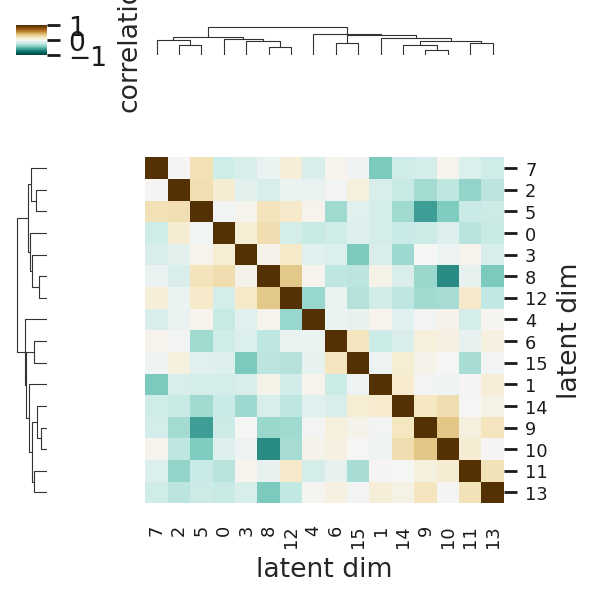

In [17]:
interscale.pl.latent_correlation(
    adata, z_key="_local_emb", vmax=1.0, cmap="BrBG_r", title="Local Embedding", figsize=(4, 4)
)
interscale.pl.latent_correlation(
    adata, z_key="_global_emb", vmax=1.0, cmap="BrBG_r", title="Global Embedding", figsize=(4, 4)
)

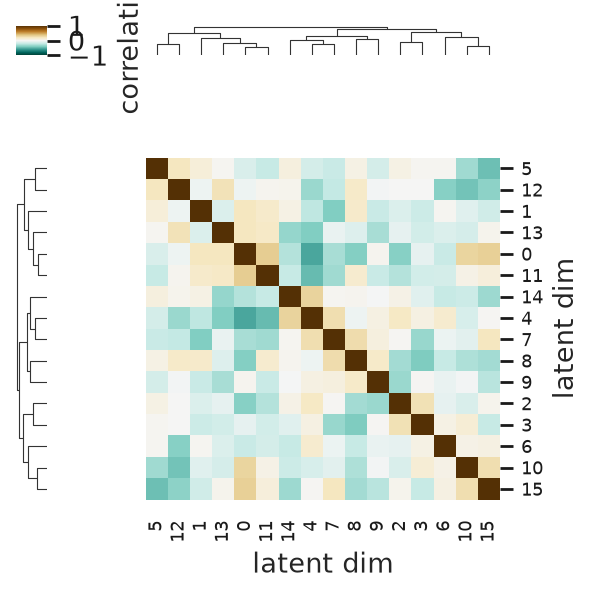

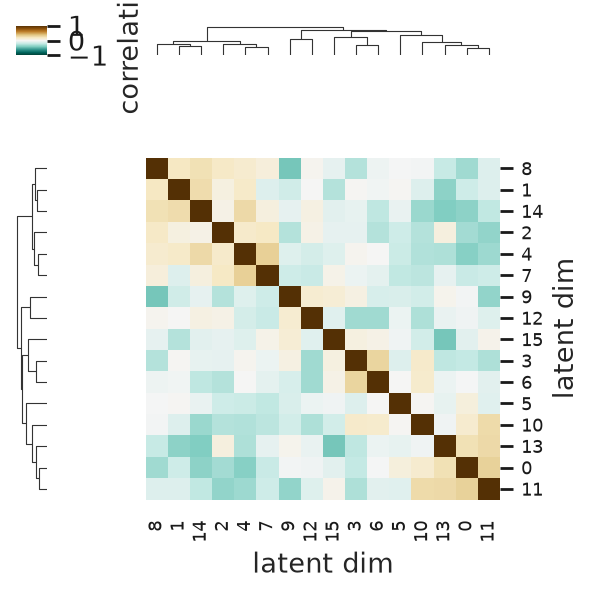

In [19]:
interscale.pl.latent_correlation(
    adata, z_key="_local_emb", vmax=1.0, cmap="BrBG_r", title="Local Embedding", figsize=(4, 4)
)
interscale.pl.latent_correlation(
    adata, z_key="_global_emb", vmax=1.0, cmap="BrBG_r", title="Global Embedding", figsize=(4, 4)
)


60% cumulative variance reached with 7 dimensions:
Embedding dimensions (sorted by importance):
[5, 15, 2, 0, 12, 8, 6]

60% cumulative variance reached with 6 dimensions:
Embedding dimensions (sorted by importance):
[8, 9, 10, 4, 13, 14]


<Axes: title={'center': 'Global Embedding Dim Importance Elbow'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

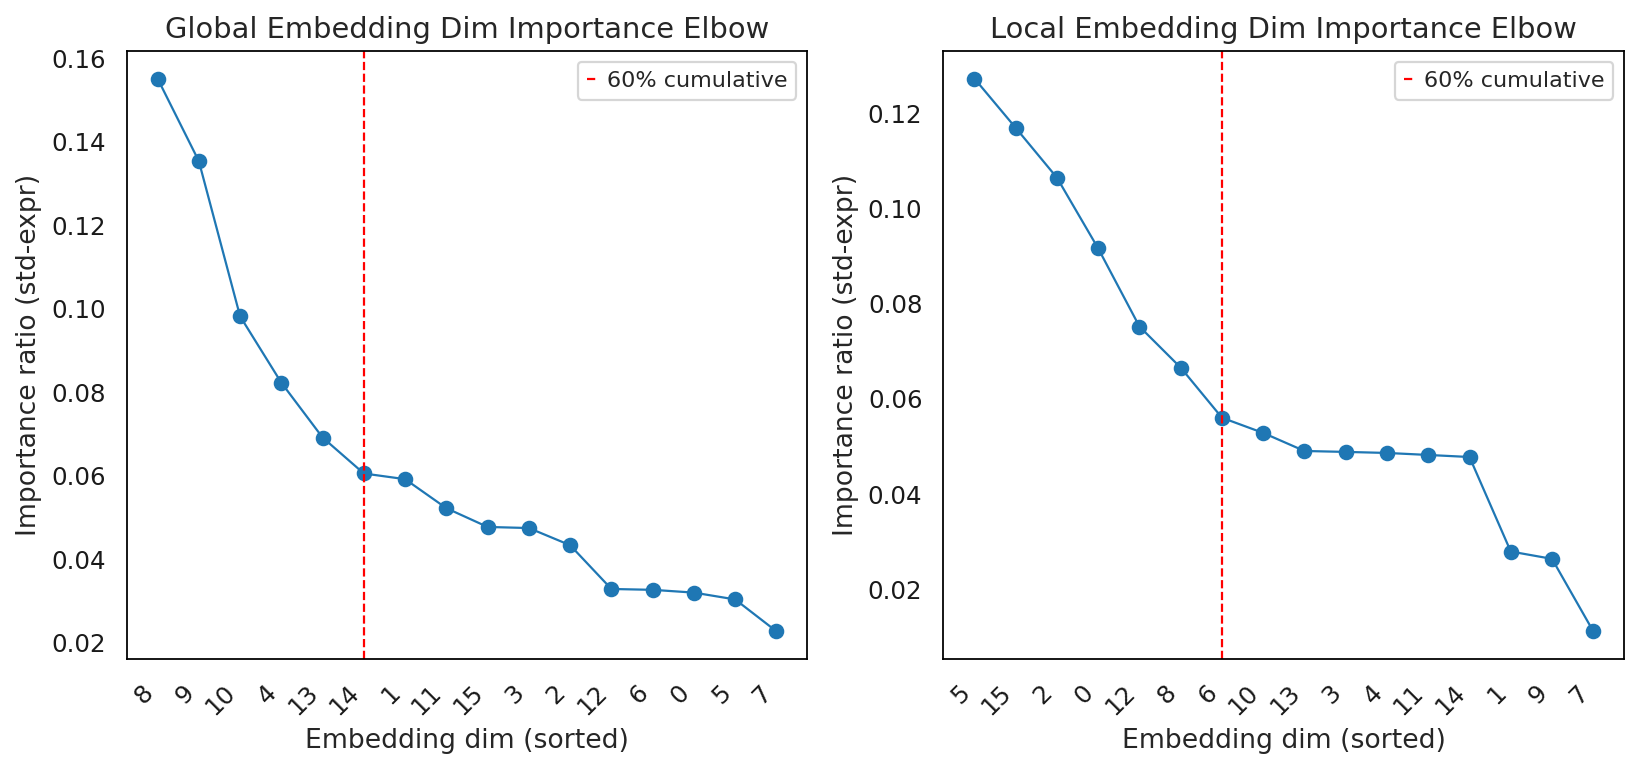

In [18]:
result_global = calculate_dim_importance(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)
result_local = calculate_dim_importance(
    adata,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
interscale.pl.dim_importance_elbow(result_local, title="Local Embedding Dim Importance Elbow", ax=axes[1])
interscale.pl.dim_importance_elbow(result_global, title="Global Embedding Dim Importance Elbow", ax=axes[0])


60% cumulative variance reached with 5 dimensions:
Embedding dimensions (sorted by importance):
[9, 2, 8, 5, 13]

60% cumulative variance reached with 6 dimensions:
Embedding dimensions (sorted by importance):
[9, 11, 7, 14, 2, 5]


<Axes: title={'center': 'Global Embedding Dim Importance Elbow'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

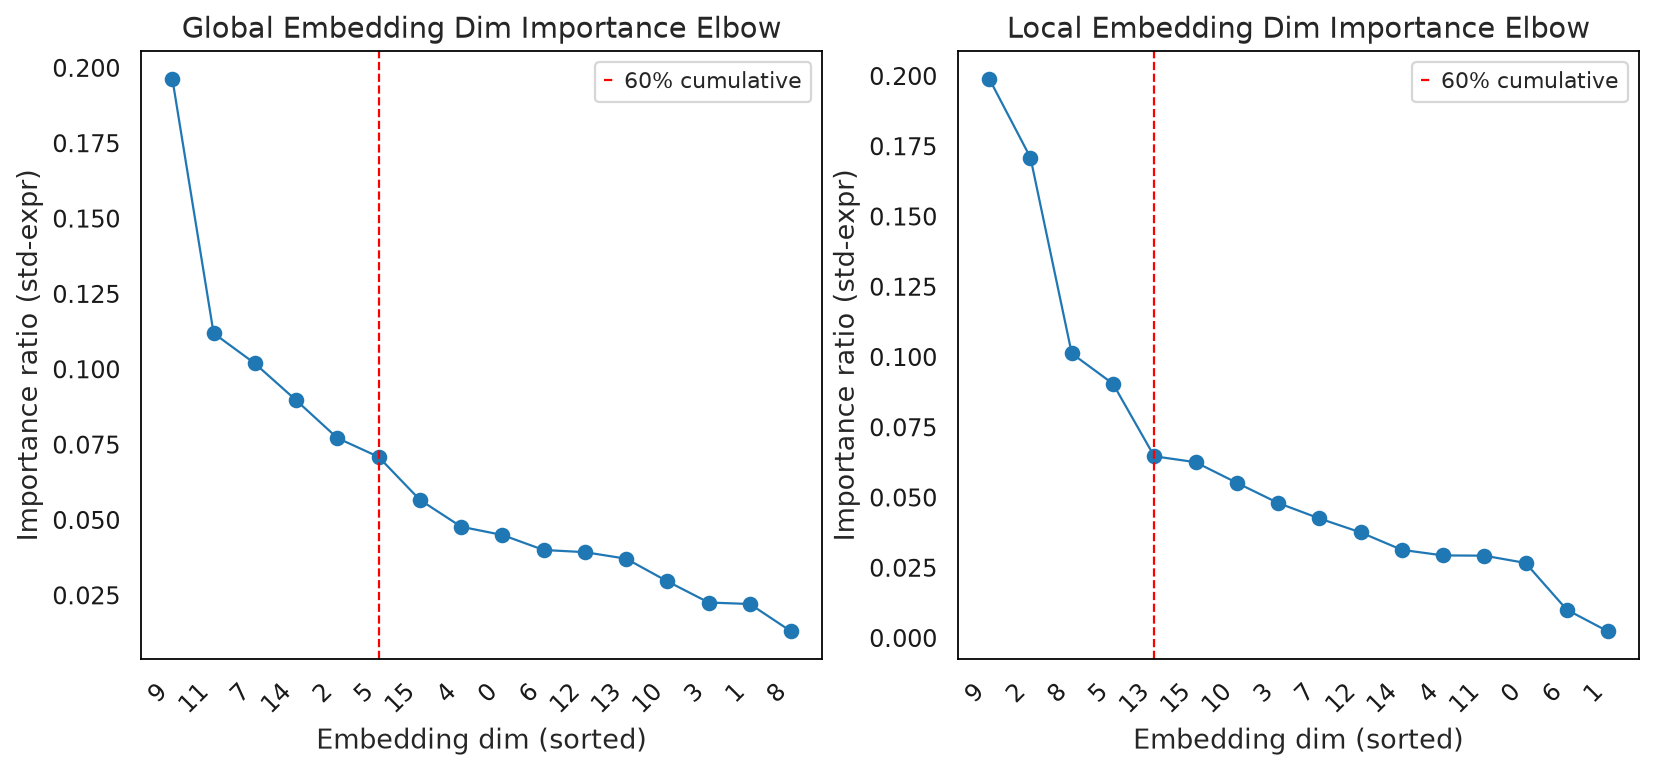

In [20]:
result_global = calculate_dim_importance(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)
result_local = calculate_dim_importance(
    adata,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",
    use_ratio=True,
    cumulative_cutoff=0.60,
    spacing=2,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
interscale.pl.dim_importance_elbow(result_local, title="Local Embedding Dim Importance Elbow", ax=axes[1])
interscale.pl.dim_importance_elbow(result_global, title="Global Embedding Dim Importance Elbow", ax=axes[0])

### Expression Filtering

| Argument | Effect |
| --- | --- |
| min_frac | Remove rare genes |
| min_sd | Remove low-variance genes |

### Scoring Choices

| Argument | Meaning |
| --- | --- |
| rank_by="loading" | Pure decoder sensitivity |
| rank_by="loading_x_sd" | Favor highly variable genes |
| residualize=True | Use only unique component of dimension |

### Specificity Control

| Argument | Meaning |
| --- | --- |
| enforce_specificity | Force genes to be dimension-specific |
| specificity_mode="ratio" | max/second criterion |
| specificity_min | How strict the specificity must be |

gene_by_dim_heatmap interpretation:

So:

- Dark brown → strong positive association with that dimension
- Dark green → strong negative association
- Near white → little association

Select the local and global dimensions. 

In [21]:
global_dim = [8, 9, 10, 4, 13, 14]
local_dim = [5, 15, 2, 0, 12, 8, 6]

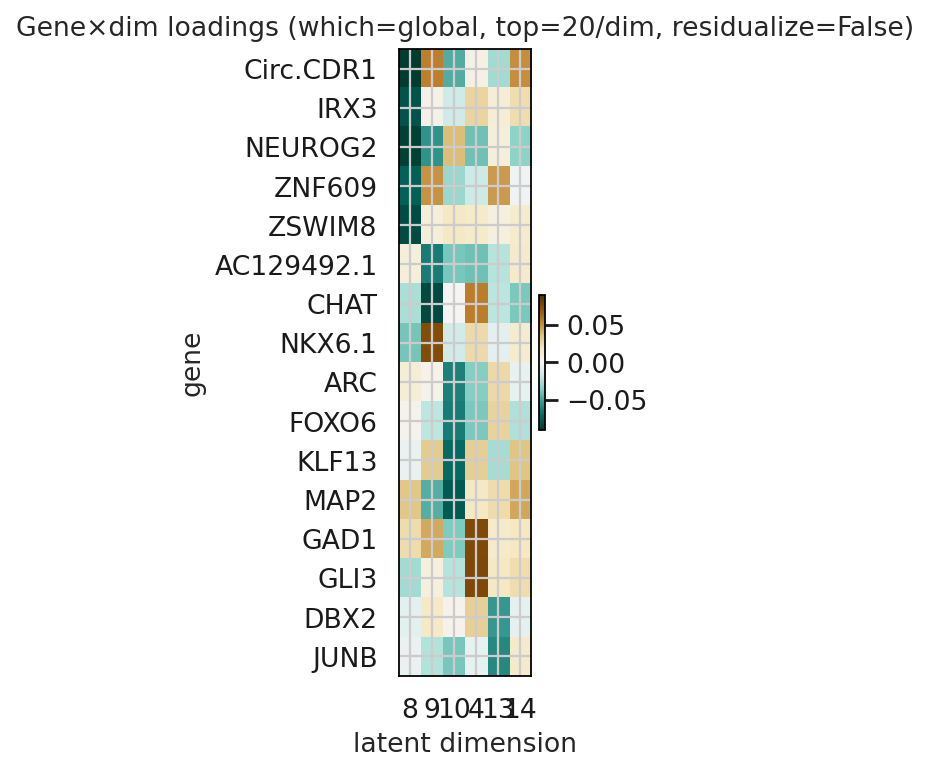

In [20]:
df_global, ax = get_genes_dim(
    adata,
    which="global",
    dims=global_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    specificity_min=1.5,
    # residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

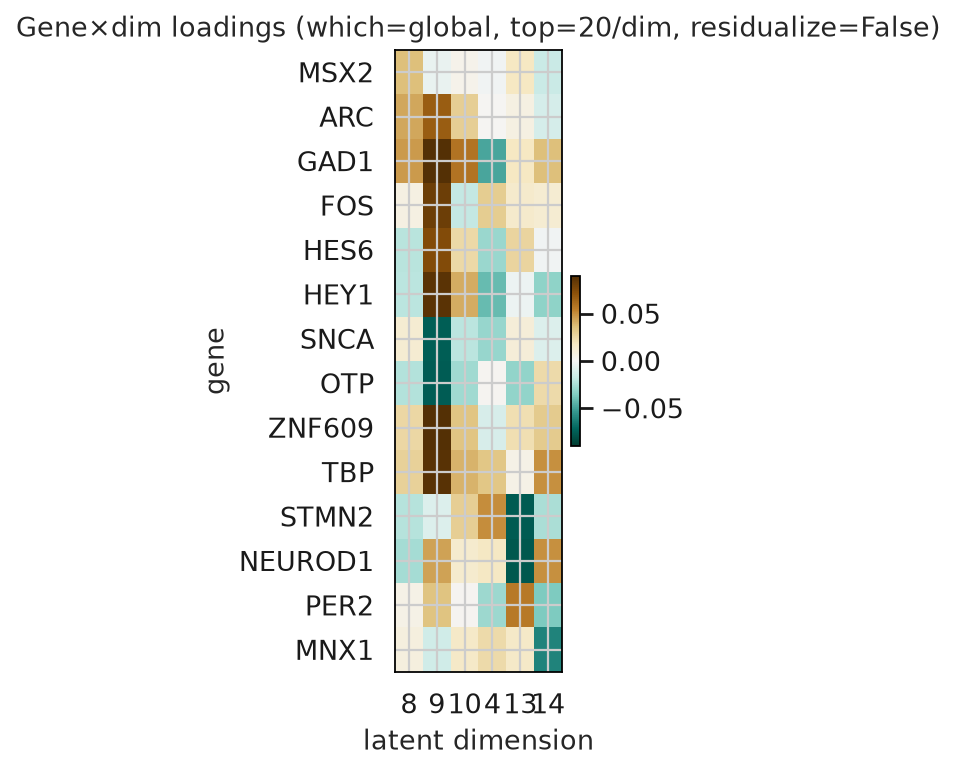

In [22]:
df_global, ax = get_genes_dim(
    adata,
    which="global",
    dims=global_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    specificity_min=1.5,
    # residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

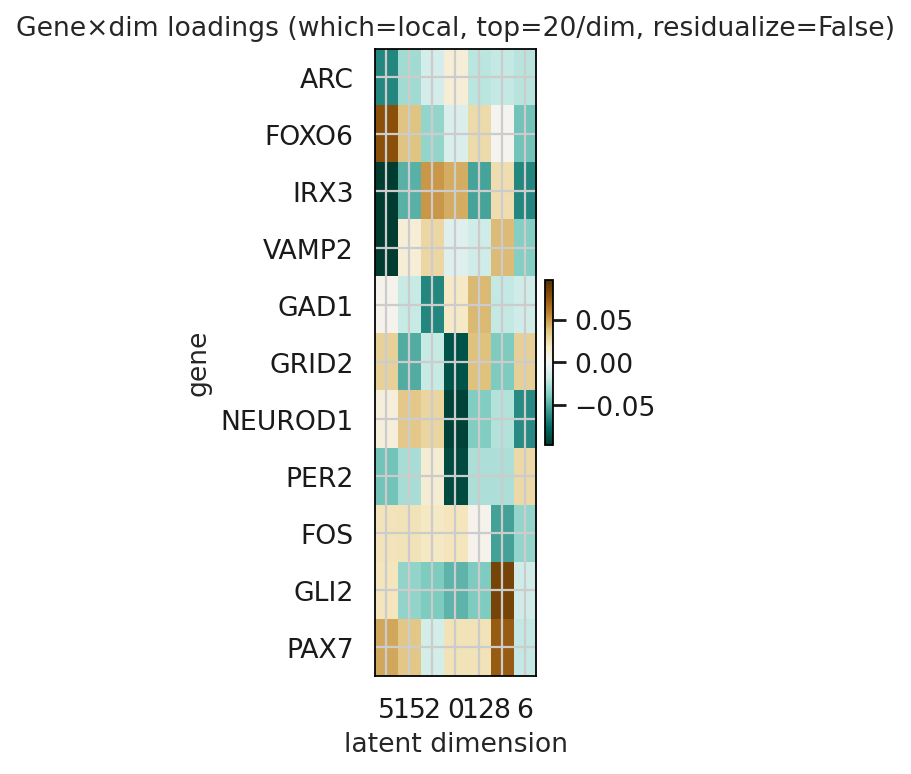

In [21]:
df_local, ax = get_genes_dim(
    adata,
    which="local",
    dims=local_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    enforce_specificity=True,
    rank_by="loading_x_sd",
    specificity_min=1.5,
    # residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

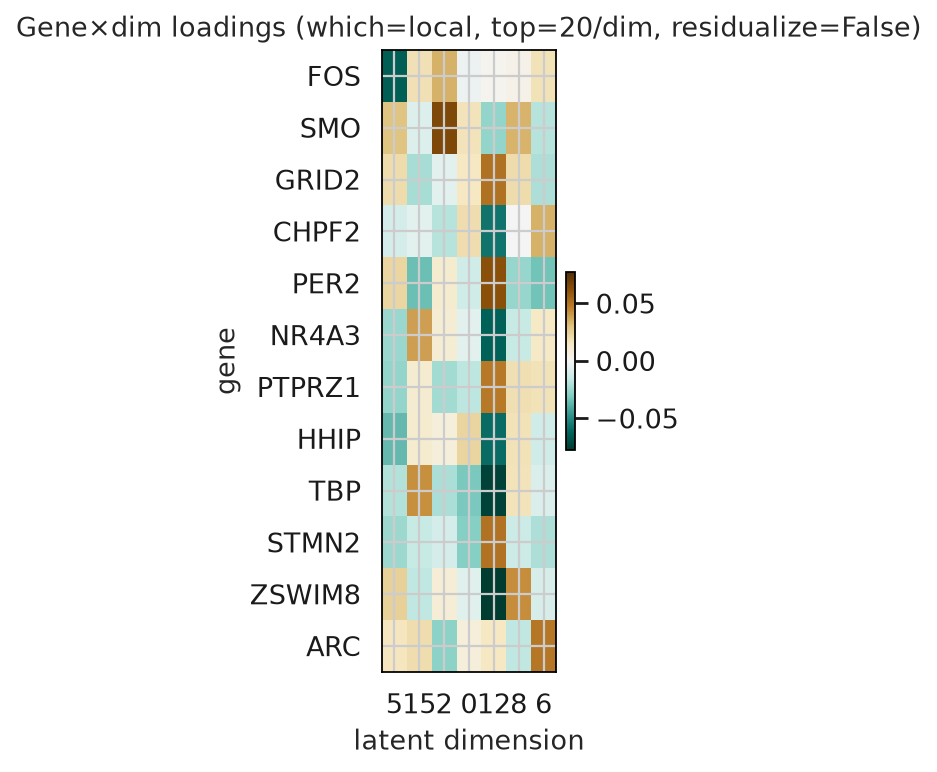

In [23]:
df_local, ax = get_genes_dim(
    adata,
    which="local",
    dims=local_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    enforce_specificity=True,
    rank_by="loading_x_sd",
    specificity_min=1.5,
    # residualize=True,
    plot=True,
    figsize=(3.3, 5),
)

## Identify gene programs

In the next step, we take those top genes associated with the local and global latent dimensions and ask whether they form coherent biological programs.

In [22]:
global_genes = df_global.index
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

Shared: ['IRX3', 'ARC', 'FOXO6', 'GAD1']
Unique local: ['FOS', 'GLI2', 'GRID2', 'NEUROD1', 'PAX7', 'PER2', 'VAMP2']
Unique global: ['AC129492.1', 'CHAT', 'Circ.CDR1', 'DBX2', 'GLI3', 'JUNB', 'KLF13', 'MAP2', 'NEUROG2', 'NKX6.1', 'ZNF609', 'ZSWIM8']


In [24]:
global_genes = df_global.index
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

Shared: ['ARC', 'FOS', 'TBP', 'STMN2', 'PER2']
Unique local: ['CHPF2', 'GRID2', 'HHIP', 'NR4A3', 'PTPRZ1', 'SMO', 'ZSWIM8']
Unique global: ['GAD1', 'HES6', 'HEY1', 'MNX1', 'MSX2', 'NEUROD1', 'OTP', 'SNCA', 'ZNF609']


In [24]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="human",  # or "Mouse"
    outdir=None,
)
enr_global.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of miRNA Catabolic Process (GO:2000...,1/5,0.002997,0.037343,0,0,454.181818,2638.914119,ZSWIM8
1,GO_Biological_Process_2025,Negative Regulation of miRNA-mediated Gene Sil...,1/6,0.003595,0.037343,0,0,363.327273,2044.882815,ZSWIM8
2,GO_Biological_Process_2025,Nose Development (GO:0043584),1/7,0.004193,0.037343,0,0,302.757576,1657.396457,GLI3
3,GO_Biological_Process_2025,Negative Regulation of Alpha-Beta T Cell Diffe...,1/8,0.004791,0.037343,0,0,259.493506,1385.975083,GLI3
4,GO_Biological_Process_2025,T Cell Apoptotic Process (GO:0070231),1/8,0.004791,0.037343,0,0,259.493506,1385.975083,GLI3


In [25]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="human",  # or "Mouse"
    outdir=None,
)
enr_global.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,7/2250,0.000007,0.001378,0,0,27.694160,330.250714,NEUROD1;HES6;ZNF609;HEY1;MSX2;OTP;SNCA
1,GO_Biological_Process_2025,Cardiac Conduction System Development (GO:0003...,2/25,0.000054,0.005586,0,0,248.049689,2438.797545,HEY1;MSX2
2,GO_Biological_Process_2025,Regulation of Nervous System Development (GO:0...,2/45,0.000176,0.008178,0,0,132.544850,1145.535735,HES6;HEY1
3,GO_Biological_Process_2025,Negative Regulation of Transcription by RNA Po...,4/732,0.000194,0.008178,0,0,21.168132,180.985822,HEY1;MSX2;OTP;SNCA
4,GO_Biological_Process_2025,Cardiac Muscle Tissue Development (GO:0048738),2/51,0.000227,0.008178,0,0,116.279883,975.707936,HEY1;MSX2


In [25]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="human",  # or "Mouse"
    outdir=None,
)
enr_local.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Response to Hexose (GO:0009746),2/25,0.000031,0.006590,0,0,347.304348,3601.323532,NEUROD1;VAMP2
1,GO_Biological_Process_2025,Central Nervous System Neuron Differentiation ...,2/46,0.000108,0.008114,0,0,181.354545,1656.578768,NEUROD1;GRID2
2,GO_Biological_Process_2025,Response to Glucose (GO:0009749),2/51,0.000133,0.008114,0,0,162.808163,1453.350008,NEUROD1;VAMP2
3,GO_Biological_Process_2025,Regulation of Peptide Hormone Secretion (GO:00...,2/55,0.000155,0.008114,0,0,150.490566,1320.548882,NEUROD1;PER2
4,GO_Biological_Process_2025,Regulation of DNA-templated Transcription (GO:...,5/2139,0.000243,0.009293,0,0,20.921978,174.126969,NEUROD1;PER2;PAX7;FOS;GLI2


In [26]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="human",  # or "Mouse"
    outdir=None,
)
enr_local.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Neuron Apoptotic Process (GO:004...,2/129,0.000849,0.019424,0,0,62.570079,442.481647,GRID2;PTPRZ1
1,GO_Biological_Process_2025,Cerebellar Granule Cell Differentiation (GO:00...,1/5,0.001749,0.019424,0,0,832.875000,5287.722500,GRID2
2,GO_Biological_Process_2025,Regulation of miRNA Catabolic Process (GO:2000...,1/5,0.001749,0.019424,0,0,832.875000,5287.722500,ZSWIM8
3,GO_Biological_Process_2025,Glutamatergic Neuron Differentiation (GO:1905962),1/5,0.001749,0.019424,0,0,832.875000,5287.722500,GRID2
4,GO_Biological_Process_2025,Prepulse Inhibition (GO:0060134),1/5,0.001749,0.019424,0,0,832.875000,5287.722500,GRID2


In [27]:
df_local = enr_local.results
df_global = enr_global.results

In [28]:
df_local["group"] = "Local"
df_global["group"] = "Global"

combined = pd.concat(
    [df_local.sort_values("Adjusted P-value").head(6), df_global.sort_values("Adjusted P-value").head(6)]
)

combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"])

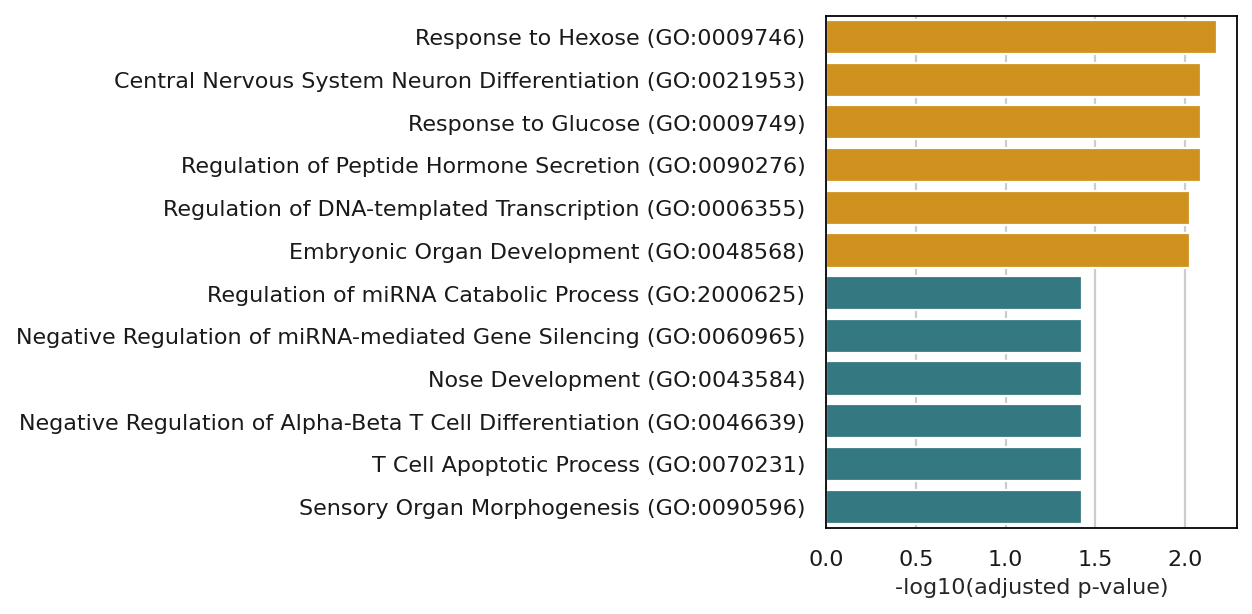

In [30]:
combined = combined.sort_values("-log10(padj)", ascending=False)

palette = {"Global": "#27828E", "Local": "#EE9B00"}

plt.figure(figsize=(8, 4))

sns.barplot(data=combined, y="Term", x="-log10(padj)", hue="group", palette=palette, legend=False)

plt.xlabel("-log10(adjusted p-value)", fontsize=10)
plt.ylabel("", fontsize=10)
# plt.title("GO enrichment: global vs local embeddings", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# plt.legend(title="", fontsize=10)

plt.tight_layout()
# plt.savefig("figures/gene_programs.png", dpi=300, bbox_inches="tight")
plt.show()

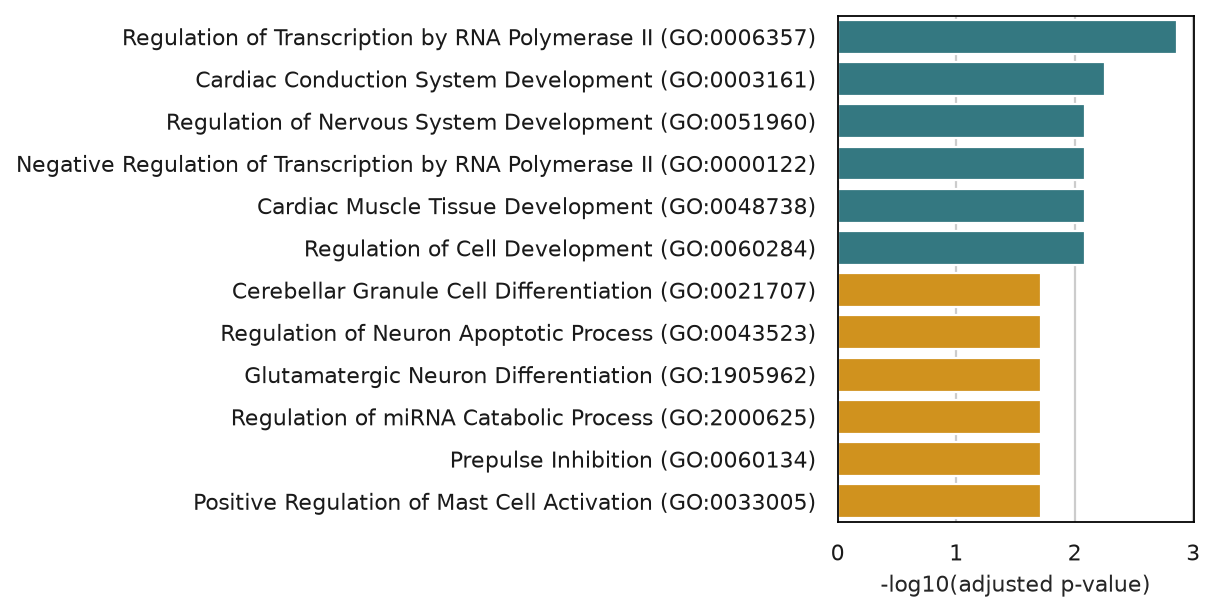

In [29]:
combined = combined.sort_values("-log10(padj)", ascending=False)

palette = {"Global": "#27828E", "Local": "#EE9B00"}

plt.figure(figsize=(8, 4))

sns.barplot(data=combined, y="Term", x="-log10(padj)", hue="group", palette=palette, legend=False)

plt.xlabel("-log10(adjusted p-value)", fontsize=10)
plt.ylabel("", fontsize=10)
# plt.title("GO enrichment: global vs local embeddings", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# plt.legend(title="", fontsize=10)

plt.tight_layout()
# plt.savefig("figures/gene_programs.png", dpi=300, bbox_inches="tight")
plt.show()

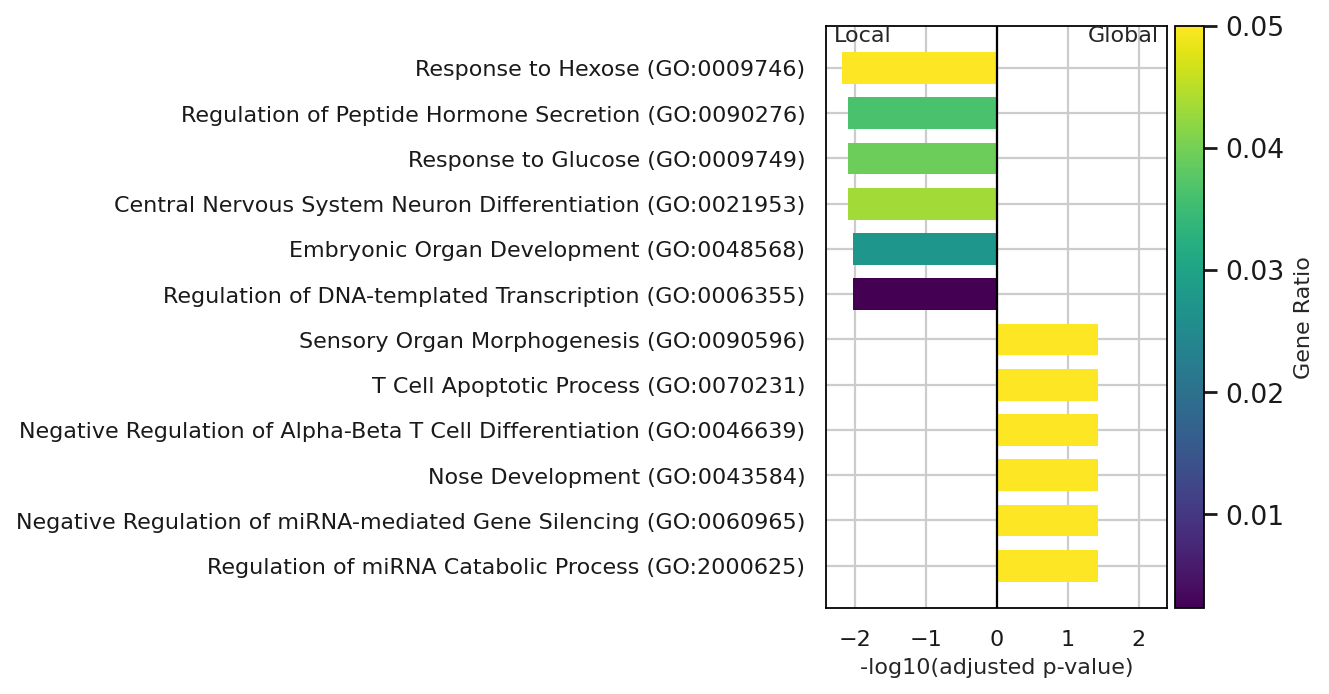

In [31]:
# --- Prepare dataframe ---
plot_df = combined.copy().reset_index(drop=True)

# --- Compute Gene Ratio ---
plot_df["gene_ratio"] = plot_df["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

# --- Clip extreme values (stabilize color contrast) ---
clip_max = 0.05  # adjust if needed
plot_df["gene_ratio_plot"] = plot_df["gene_ratio"].clip(upper=clip_max)

# --- Signed values for diverging bars ---
plot_df["signed_log10"] = plot_df["-log10(padj)"]
plot_df.loc[plot_df["group"] == "Local", "signed_log10"] *= -1

# --- Sort by absolute significance ---
plot_df = plot_df.sort_values(by="signed_log10", key=lambda s: s.abs(), ascending=True).reset_index(drop=True)

# --- Colormap setup ---
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=plot_df["gene_ratio_plot"].min(), vmax=plot_df["gene_ratio_plot"].max())

# --- Create figure ---
fig, ax = plt.subplots(figsize=(8, 4.5))

# --- Plot bars ---
ax.barh(
    y=plot_df["Term"],
    width=plot_df["signed_log10"],
    color=cmap(norm(plot_df["gene_ratio_plot"])),
    edgecolor="none",
    height=0.7,
)

# --- Center line ---
ax.axvline(0, color="black", linewidth=1)

# --- Symmetric x-limits ---
max_val = plot_df["-log10(padj)"].max()
ax.set_xlim(-max_val * 1.1, max_val * 1.1)

# --- Labels ---
ax.set_xlabel("-log10(adjusted p-value)", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# --- Optional group labels ---
ax.text(-max_val * 1.05, len(plot_df) - 0.5, "Local", ha="left", va="bottom", fontsize=10)
ax.text(max_val * 1.05, len(plot_df) - 0.5, "Global", ha="right", va="bottom", fontsize=10)

# --- Colorbar ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Gene Ratio", fontsize=10)

# --- Layout & save ---
plt.tight_layout()
plt.savefig("../../../figures/gene_programs_diverging_gene_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

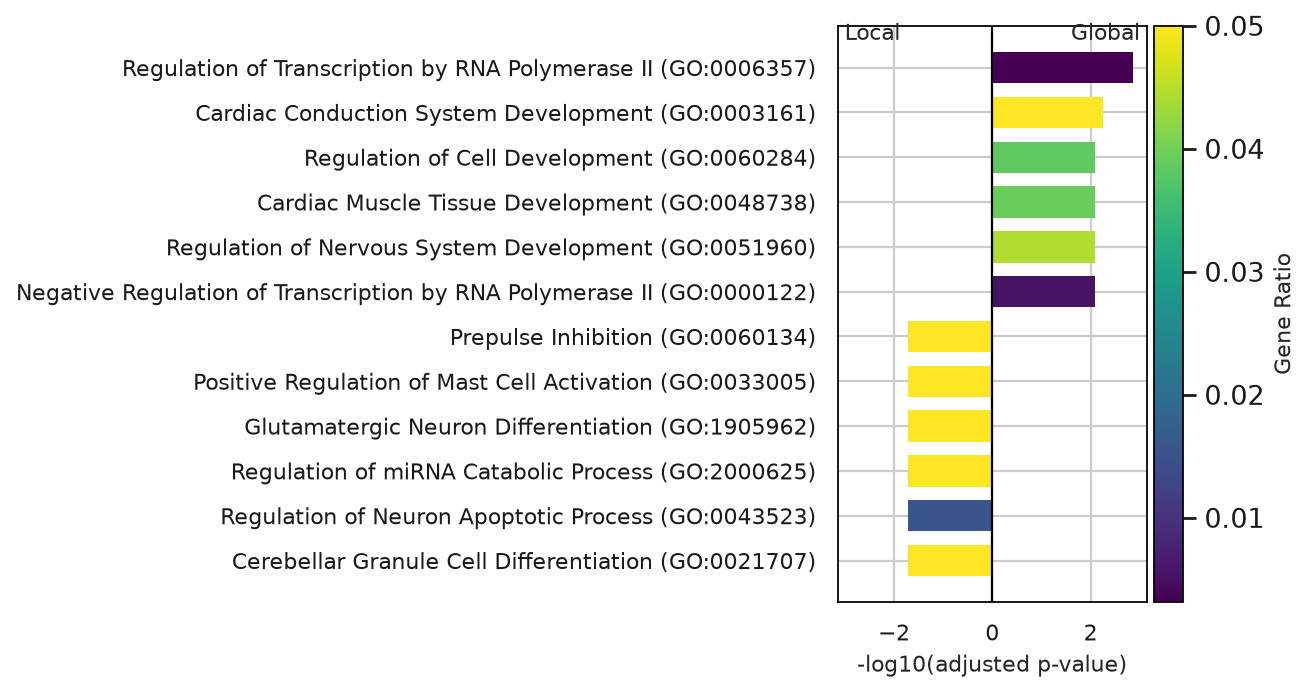

In [33]:
# --- Prepare dataframe ---
plot_df = combined.copy().reset_index(drop=True)

# --- Compute Gene Ratio ---
plot_df["gene_ratio"] = plot_df["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

# --- Clip extreme values (stabilize color contrast) ---
clip_max = 0.05  # adjust if needed
plot_df["gene_ratio_plot"] = plot_df["gene_ratio"].clip(upper=clip_max)

# --- Signed values for diverging bars ---
plot_df["signed_log10"] = plot_df["-log10(padj)"]
plot_df.loc[plot_df["group"] == "Local", "signed_log10"] *= -1

# --- Sort by absolute significance ---
plot_df = plot_df.sort_values(by="signed_log10", key=lambda s: s.abs(), ascending=True).reset_index(drop=True)

# --- Colormap setup ---
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=plot_df["gene_ratio_plot"].min(), vmax=plot_df["gene_ratio_plot"].max())

# --- Create figure ---
fig, ax = plt.subplots(figsize=(8, 4.5))

# --- Plot bars ---
ax.barh(
    y=plot_df["Term"],
    width=plot_df["signed_log10"],
    color=cmap(norm(plot_df["gene_ratio_plot"])),
    edgecolor="none",
    height=0.7,
)

# --- Center line ---
ax.axvline(0, color="black", linewidth=1)

# --- Symmetric x-limits ---
max_val = plot_df["-log10(padj)"].max()
ax.set_xlim(-max_val * 1.1, max_val * 1.1)

# --- Labels ---
ax.set_xlabel("-log10(adjusted p-value)", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# --- Optional group labels ---
ax.text(-max_val * 1.05, len(plot_df) - 0.5, "Local", ha="left", va="bottom", fontsize=10)
ax.text(max_val * 1.05, len(plot_df) - 0.5, "Global", ha="right", va="bottom", fontsize=10)

# --- Colorbar ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Gene Ratio", fontsize=10)

# --- Layout & save ---
plt.tight_layout()
plt.savefig("/home/lehnerl/Arbeit/results/figures/gene_programs_diverging_gene_ratio.png", dpi=300, bbox_inches="tight")
plt.show()